In [9]:
import pickle

with open("insight_student_embeddings_test.pkl", "rb") as f:
    embeddings = pickle.load(f)

In [12]:
embeddings["filenames"] = sum(embeddings["filenames"], [])

In [ ]:
id_to_embedding = {}
for i in range(len(embeddings["filenames"])):
    id = embeddings["filenames"][i].replace("/path/to/ms1m-arcface/", "").split("/")[0]
    exsting = id_to_embedding.get(id, [])
    exsting.append({
        "teacher": embeddings["teacher_embeddings"][i],
        "student": embeddings["student_embeddings"][i],
    })

    id_to_embedding[id] = exsting

In [23]:
import torch
embeddings = {"teacher": [], "student": []}
embeddings_another = {"teacher": [], "student": []}
for key in id_to_embedding:
    items = id_to_embedding[key]
    if len(items) < 2:
        continue
    embeddings["teacher"].append(items[0]["teacher"])
    embeddings["student"].append(items[0]["student"]) 
    embeddings_another["teacher"].append(items[1]["teacher"])
    embeddings_another["student"].append(items[1]["student"])

embeddings["teacher"] = torch.stack(embeddings["teacher"], dim=0)
embeddings["student"] = torch.stack(embeddings["student"], dim=0)
embeddings_another["teacher"] = torch.stack(embeddings_another["teacher"], dim=0)
embeddings_another["student"] = torch.stack(embeddings_another["student"], dim=0)

In [24]:
df = []
for comb in [("student", "teacher"), ("teacher", "student"), ("teacher", "teacher"), ("student", "student")]:
    student_embeddings = embeddings[comb[0]]
    teacher_embeddings = embeddings_another[comb[1]]
    if len(teacher_embeddings.shape) == 3:
        teacher_embeddings = teacher_embeddings[:,0]
    if len(student_embeddings.shape) == 3:
        student_embeddings = student_embeddings[:,0]
    rank = []
    import torch
    for i in range(len(student_embeddings)):
        sims = student_embeddings[i].cpu() @ teacher_embeddings.T
        # sims = original_features_another_list[i].cpu() @ original_features_list.T
        prders = torch.argsort(sims, descending=True)
        rank.append(torch.where(prders == i)[0].item()/len(prders))
    import pandas as pd 
    df.extend([{ 
        "query": "Template" if comb[0] == "student" else "Face",
        "gallery": "Template" if comb[1] == "student" else "Face",
        "recall@0%": sum([1 for r in rank if r <= 0.0]) / len(rank),
        "recall@0.02%": sum([1 for r in rank if r <= 0.0002]) / len(rank),
        "recall@0.05%": sum([1 for r in rank if r <= 0.0005]) / len(rank),
        "recall@0.1%": sum([1 for r in rank if r <= 0.001]) / len(rank),
        "recall@1%": sum([1 for r in rank if r <= 0.01]) / len(rank),
        "recall@5%": sum([1 for r in rank if r <= 0.05]) / len(rank),
        "mean_rank": sum(rank) / len(rank) 
    }])

In [25]:
df = pd.DataFrame(df)

In [26]:
df

,query,gallery,recall@0%,recall@0.02%,recall@0.05%,recall@0.1%,recall@1%,recall@5%,mean_rank
0,Template,Face,0.913177,0.942235,0.956029,0.963100,0.976124,0.983686,0.006193
1,Face,Template,0.905125,0.938734,0.953928,0.959950,0.975214,0.983126,0.006698
2,Face,Face,0.950147,0.964151,0.969962,0.972903,0.979625,0.984386,0.005900
3,Template,Template,0.840639,0.893572,0.923960,0.938524,0.968982,0.980325,0.007205


In [31]:
print(df.to_latex(float_format="%.4f").replace("%", "\\%")) 

\begin{tabular}{lllrrrrrrr}
\toprule
 & query & gallery & recall@0\% & recall@0.02\% & recall@0.05\% & recall@0.1\% & recall@1\% & recall@5\% & mean_rank \\
\midrule
0 & Template & Face & 0.9132 & 0.9422 & 0.9560 & 0.9631 & 0.9761 & 0.9837 & 0.0062 \\
1 & Face & Template & 0.9051 & 0.9387 & 0.9539 & 0.9599 & 0.9752 & 0.9831 & 0.0067 \\
2 & Face & Face & 0.9501 & 0.9642 & 0.9700 & 0.9729 & 0.9796 & 0.9844 & 0.0059 \\
3 & Template & Template & 0.8406 & 0.8936 & 0.9240 & 0.9385 & 0.9690 & 0.9803 & 0.0072 \\
\bottomrule
\end{tabular}



In [77]:
import numpy as np
import matplotlib.pyplot as plt
import pylab
counts, bins = np.histogram(rank, bin   
rel = counts / counts.sum()
plt.bar(bins[:-1], rel, width=np.diff(bins), align='edge')
pylab.xlabel("Normalized Rank")
pylab.ylabel("Frequency")
pylab.title("Histogram of Normalized Ranks")
plt.show()

SyntaxError: invalid syntax (2089493354.py, line 5)

In [ ]:
import pandas as pd
df = pd.DataFrame([{
    "recall@0%": sum([1 for r in rank if r <= 0.0]) / len(rank),
    "recall@0.02%": sum([1 for r in rank if r <= 0.0002]) / len(rank),
    "recall@0.05%": sum([1 for r in rank if r <= 0.0005]) / len(rank),
    "recall@0.1%": sum([1 for r in rank if r <= 0.001]) / len(rank),
    "recall@1%": sum([1 for r in rank if r <= 0.01]) / len(rank),
    "recall@5%": sum([1 for r in rank if r <= 0.05]) / len(rank),
    "mean_rank": sum(rank) / len(rank) 
}])

In [ ]:
df.T 

,0
recall@0%,0.252478
recall@0.02%,0.325364
recall@0.05%,0.370651
recall@0.1%,0.441983
recall@1%,0.701458
recall@5%,0.873275
mean_rank,0.031111


In [ ]:
random_list = {"drink":{"coffee":0.45,"water":0.25,"tea":0.10,"soda":0.15,"alcoholic_drinks":0.05},"fruit":{"apple":0.25,"banana":0.20,"berries":0.20,"orange":0.15,"grapes":0.10,"other":0.10},"watched_family_guy":{"yes":0.60,"no":0.40},"workout_regularly":{"yes":0.45,"no":0.55},"device_os":{"iOS":0.40,"Android":0.40, "PC/Mac":0.20}}

In [ ]:
student_embeddings = embeddings["student"]
teacher_embeddings = embeddings_another["teacher"]

In [ ]:
import random
random_attributes = [] 
for i in range(len(student_embeddings)):
  random_attribute = []
  for cat in random_list.keys():
    random_attribute.append(np.random.choice(list(random_list[cat].keys()), p=list(random_list[cat].values())).item())
  random_attributes.append(str(random_attribute))

In [ ]:

rank = []
import torch
for i in range(len(student_embeddings)):
    exclude_id = np.where(np.array(random_attributes) != random_attributes[i])[0]
    sims = student_embeddings[i].cpu() @ teacher_embeddings.T
    sims[exclude_id] = -float('inf')
    # sims = original_features_another_list[i].cpu() @ original_features_list.T
    prders = torch.argsort(sims, descending=True)
    rank.append(torch.where(prders == i)[0].item()/len(prders))
import pandas as pd

In [ ]:
print(pd.DataFrame([{ 
    "recall@0%": sum([1 for r in rank if r <= 0.0]) / len(rank),
    "recall@0.02%": sum([1 for r in rank if r <= 0.0002]) / len(rank),
    "recall@0.05%": sum([1 for r in rank if r <= 0.0005]) / len(rank),
    "recall@0.1%": sum([1 for r in rank if r <= 0.001]) / len(rank),
    "recall@1%": sum([1 for r in rank if r <= 0.01]) / len(rank),
    "recall@5%": sum([1 for r in rank if r <= 0.05]) / len(rank),
    "mean_rank": sum(rank) / len(rank) 
}]))

   recall@0%  recall@0.02%  recall@0.05%  recall@0.1%  recall@1%  recall@5%  \
0   0.860253      0.917784      0.940914     0.968513        1.0        1.0   

   mean_rank  
0   0.000127  


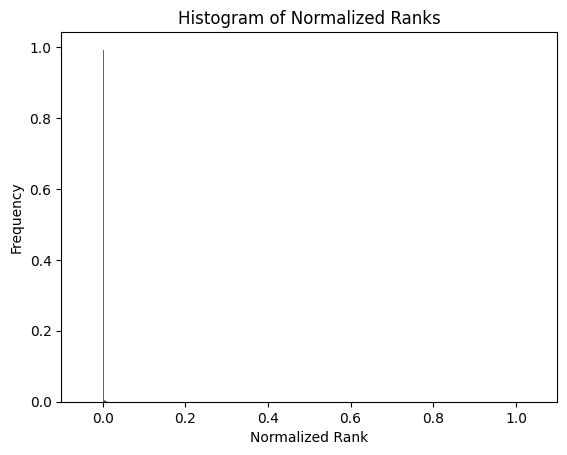

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pylab
counts, bins = np.histogram(rank, bins=300, range=(0,1))
rel = counts / counts.sum()
plt.bar(bins[:-1], rel, width=np.diff(bins), align='edge')
pylab.xlabel("Normalized Rank")
pylab.ylabel("Frequency")
pylab.title("Histogram of Normalized Ranks")
pylab.xlim(-0.1, 1.1)
# pylab.yscale('log')
plt.show()

In [83]:
# face to face
emb_1 = embeddings_another["teacher"][:,0]
emb_2 = embeddings["teacher"][:,0]
sims_image = torch.nn.functional.cosine_similarity(emb_1, emb_2, dim=1).cpu().detach().numpy()

In [84]:
# template to face
emb_1 = embeddings["teacher"][:,0]
emb_2 = embeddings["student"]
sims_template_to_image = torch.nn.functional.cosine_similarity(emb_1, emb_2, dim=1).cpu().detach().numpy()

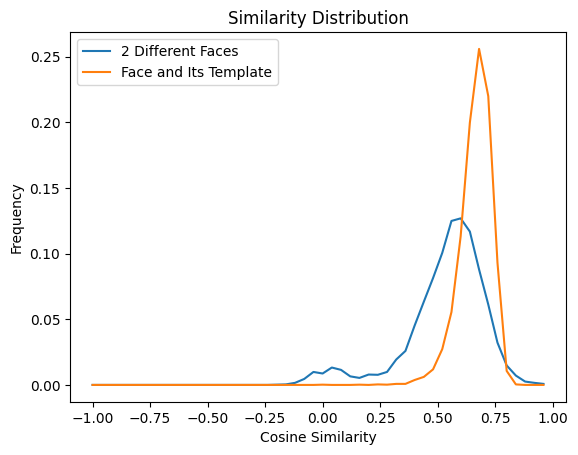

In [85]:
import pylab
import numpy as np
hist_image = np.histogram(sims_image, bins=50, range=(-1,1))
hist_template_to_image = np.histogram(sims_template_to_image, bins=50, range=(-1,1))
pylab.plot(hist_image[1][:-1], hist_image[0]/hist_image[0].sum(), label="2 Different Faces")
pylab.plot(hist_template_to_image[1][:-1], hist_template_to_image[0]/hist_template_to_image[0].sum(), label="Face and Its Template")
pylab.xlabel("Cosine Similarity")
pylab.ylabel("Frequency") 
pylab.title("Similarity Distribution") 
pylab.legend()

In [86]:
# paired rank test
from scipy import stats
stats.wilcoxon(sims_image, sims_template_to_image, alternative='less')


WilcoxonResult(statistic=1393357.5, pvalue=0.0)